<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 210%;text-align: center;border-radius: 10px 70px">
    Time Series Analysis and Forecasting
</center></p></h1>

<a class="anchor" id="setup"></a>
<br>
<br>
<br>
<font style="font-family:Gabriola; font-size:300%;">1️⃣ Step 1 | About Dataset </font><br>
 <br>   
<br>

<div style="border-radius: 5px; font-family: cursive; border: 3px solid #008000; text-align: justify; color: black; font-size: 14px; padding: 10px; background:#F2FFFF;">

  <p style="text-align: justify; font-family: cursive; font-size: 14px; color: black;">
         predict sales for the thousands of product families sold at Favorita stores located in Ecuador. The training data includes dates, store and product information, whether that item was being promoted, as well as the sales numbers. 
  </p>

  <p style="text-align: justify; font-family: cursive; font-size: 14px; color: green; font-weight: bold;">
        File Descriptions and Data Field Information
  </p>

  <ul style="font-family: cursive; font-size: 14px; color: black;">
        <li><strong>train.csv:</strong> The training data, comprising time series of features store_nbr, family, and onpromotion as well as the target sales. store_nbr identifies the store at which the products are sold. family identifies the type of product sold. sales gives the total sales for a product family at a particular store at a given date. Fractional values are possible since products can be sold in fractional units (1.5 kg of cheese, for instance, as opposed to 1 bag of chips). onpromotion gives the total number of items in a product family that were being promoted at a store at a given date.</li>
        <li><strong>test.csv:</strong> The test data, having the same features as the training data. You will predict the target sales for the dates in this file. The dates in the test data are for the 15 days after the last date in the training data.</li>
        <li><strong>sample_submission.csv:</strong> A sample submission file in the correct format.</li>
        <li><strong>stores.csv:</strong> Store metadata, including city, state, type, and cluster. cluster is a grouping of similar stores.</li>
        <li><strong>oil.csv:</strong> Daily oil price. Includes values during both the train and test data timeframes. (Ecuador is an oil-dependent country and its economy is highly vulnerable to shocks in oil prices.)</li>
        <li><strong>holidays_events.csv:</strong> Holidays and Events, with metadata. NOTE: Pay special attention to the transferred column. A holiday that is transferred officially falls on that calendar day, but was moved to another date by the government. A transferred day is more like a normal day than a holiday. To find the day that it was actually celebrated, look for the corresponding row where type is Transfer. For example, the holiday Independencia de Guayaquil was transferred from 2012-10-09 to 2012-10-12, which means it was celebrated on 2012-10-12. Days that are type Bridge are extra days that are added to a holiday (e.g., to extend the break across a long weekend). These frequently made up by the type Work Day which is a day not normally scheduled for work (such as Saturday) meant to pay back the Bridge. Additional holidays are days added to a regular calendar holiday, for example, as typically happens around Christmas (like Christmas Eve).</li>
  </ul>

</div>


https://www.kaggle.com/code/mercyogunsola/store-sales-forecasting

In [27]:
import numpy as np
import pandas as pd
import datetime
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import plotly.subplots as sp
import plotly.graph_objects as go

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose
import itertools
from prophet import Prophet
from scipy import stats 
from scipy.stats import pearsonr



import warnings 
warnings.filterwarnings('ignore')

<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
      Data Loading  
</center></p></h1>

In [2]:
train_df = pd.read_csv(r'D:\Data Analysis- Scientist\Mchine Learning\Projects\Dataset for energy\Time series - Sale and Energy\2.sale forcating\train.csv')
test_df = pd.read_csv(r'D:\Data Analysis- Scientist\Mchine Learning\Projects\Dataset for energy\Time series - Sale and Energy\2.sale forcating\test.csv')
oil_df = pd.read_csv(r'D:\Data Analysis- Scientist\Mchine Learning\Projects\Dataset for energy\Time series - Sale and Energy\2.sale forcating\oil.csv')
transaction_df = pd.read_csv(r'D:\Data Analysis- Scientist\Mchine Learning\Projects\Dataset for energy\Time series - Sale and Energy\2.sale forcating\transactions.csv')
stores_df = pd.read_csv(r'D:\Data Analysis- Scientist\Mchine Learning\Projects\Dataset for energy\Time series - Sale and Energy\2.sale forcating\stores.csv')
holiday_event_df = pd.read_csv(r'D:\Data Analysis- Scientist\Mchine Learning\Projects\Dataset for energy\Time series - Sale and Energy\2.sale forcating\holidays_events.csv')

In [3]:
train_df.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [4]:
test_df.head()

,id,date,store_nbr,family,onpromotion
0,3000888,2017-08-16,1,AUTOMOTIVE,0
1,3000889,2017-08-16,1,BABY CARE,0
2,3000890,2017-08-16,1,BEAUTY,2
3,3000891,2017-08-16,1,BEVERAGES,20
4,3000892,2017-08-16,1,BOOKS,0


In [5]:
oil_df.head()

,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20


In [6]:
transaction_df.head()

,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922


In [7]:
stores_df.head()

,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4


In [8]:
holiday_event_df.head()

,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False


##  Merging datasets holiday_event_df, stores_df, oil_df & train_df

In [9]:
train_df=train_df.merge(stores_df, on='store_nbr')
train_df.head()

,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13
1,1,2013-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13
2,2,2013-01-01,1,BEAUTY,0.0,0,Quito,Pichincha,D,13
3,3,2013-01-01,1,BEVERAGES,0.0,0,Quito,Pichincha,D,13
4,4,2013-01-01,1,BOOKS,0.0,0,Quito,Pichincha,D,13


In [10]:
train_df = train_df.merge(oil_df, on ='date', how='left')
train_df

,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster,dcoilwtico
0,0,2013-01-01,1,AUTOMOTIVE,0.000,0,Quito,Pichincha,D,13,NaN
1,1,2013-01-01,1,BABY CARE,0.000,0,Quito,Pichincha,D,13,NaN
2,2,2013-01-01,1,BEAUTY,0.000,0,Quito,Pichincha,D,13,NaN
3,3,2013-01-01,1,BEVERAGES,0.000,0,Quito,Pichincha,D,13,NaN
4,4,2013-01-01,1,BOOKS,0.000,0,Quito,Pichincha,D,13,NaN
...,...,...,...,...,...,...,...,...,...,...,...
3000883,3000883,2017-08-15,9,POULTRY,438.133,0,Quito,Pichincha,B,6,47.57
3000884,3000884,2017-08-15,9,PREPARED FOODS,154.553,1,Quito,Pichincha,B,6,47.57
3000885,3000885,2017-08-15,9,PRODUCE,2419.729,148,Quito,Pichincha,B,6,47.57
3000886,3000886,2017-08-15,9,SCHOOL AND OFFICE SUPPLIES,121.000,8,Quito,Pichincha,B,6,47.57


In [11]:
holiday_event_df = holiday_event_df.rename(columns={'type': 'holiday_type'})
holiday_event_df

,date,holiday_type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False
...,...,...,...,...,...,...
345,2017-12-22,Additional,National,Ecuador,Navidad-3,False
346,2017-12-23,Additional,National,Ecuador,Navidad-2,False
347,2017-12-24,Additional,National,Ecuador,Navidad-1,False
348,2017-12-25,Holiday,National,Ecuador,Navidad,False


In [12]:
train_df = train_df.merge(holiday_event_df, on='date', how='left')
train_df

,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster,dcoilwtico,holiday_type,locale,locale_name,description,transferred
0,0,2013-01-01,1,AUTOMOTIVE,0.000,0,Quito,Pichincha,D,13,NaN,Holiday,National,Ecuador,Primer dia del ano,False
1,1,2013-01-01,1,BABY CARE,0.000,0,Quito,Pichincha,D,13,NaN,Holiday,National,Ecuador,Primer dia del ano,False
2,2,2013-01-01,1,BEAUTY,0.000,0,Quito,Pichincha,D,13,NaN,Holiday,National,Ecuador,Primer dia del ano,False
3,3,2013-01-01,1,BEVERAGES,0.000,0,Quito,Pichincha,D,13,NaN,Holiday,National,Ecuador,Primer dia del ano,False
4,4,2013-01-01,1,BOOKS,0.000,0,Quito,Pichincha,D,13,NaN,Holiday,National,Ecuador,Primer dia del ano,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3054343,3000883,2017-08-15,9,POULTRY,438.133,0,Quito,Pichincha,B,6,47.57,Holiday,Local,Riobamba,Fundacion de Riobamba,False
3054344,3000884,2017-08-15,9,PREPARED FOODS,154.553,1,Quito,Pichincha,B,6,47.57,Holiday,Local,Riobamba,Fundacion de Riobamba,False
3054345,3000885,2017-08-15,9,PRODUCE,2419.729,148,Quito,Pichincha,B,6,47.57,Holiday,Local,Riobamba,Fundacion de Riobamba,False
3054346,3000886,2017-08-15,9,SCHOOL AND OFFICE SUPPLIES,121.000,8,Quito,Pichincha,B,6,47.57,Holiday,Local,Riobamba,Fundacion de Riobamba,False


<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
      Basic Understanding Data  
</center></p></h1>

In [13]:
# -------------------------------
# Basic Info About Dataset
# -------------------------------

print("Shape of dataset:", train_df.shape)
print("\n")

print("Dataset head:")
print(train_df.head())
print("\n")

print("Dataset info:")
train_df.info()
print("\n")

print("Description of numerical columns:")
print(train_df.describe().transpose())
print("\n")

# -------------------------------
# Checking for Duplicates
# -------------------------------

print("Number of duplicate rows:", train_df.duplicated().sum())
print("\n")

# -------------------------------
# Column Data Types
# -------------------------------

print("Column data types:")
print(train_df.dtypes)


Shape of dataset: (3054348, 16)


Dataset head:
   id        date  store_nbr      family  sales  onpromotion   city  \
0   0  2013-01-01          1  AUTOMOTIVE    0.0            0  Quito   
1   1  2013-01-01          1   BABY CARE    0.0            0  Quito   
2   2  2013-01-01          1      BEAUTY    0.0            0  Quito   
3   3  2013-01-01          1   BEVERAGES    0.0            0  Quito   
4   4  2013-01-01          1       BOOKS    0.0            0  Quito   

       state type  cluster  dcoilwtico holiday_type    locale locale_name  \
0  Pichincha    D       13         NaN      Holiday  National     Ecuador   
1  Pichincha    D       13         NaN      Holiday  National     Ecuador   
2  Pichincha    D       13         NaN      Holiday  National     Ecuador   
3  Pichincha    D       13         NaN      Holiday  National     Ecuador   
4  Pichincha    D       13         NaN      Holiday  National     Ecuador   

          description transferred  
0  Primer dia del ano     

## Handle missing values

In [15]:
# Check for missing values
train_df.isnull().sum()

id                    0
date                  0
store_nbr             0
family                0
sales                 0
onpromotion           0
city                  0
state                 0
type                  0
cluster               0
dcoilwtico       955152
holiday_type    2551824
locale          2551824
locale_name     2551824
description     2551824
transferred     2551824
dtype: int64

In [14]:
#percentage of missing values in train_df 

missing_percentages = train_df.isnull().sum()/ len(train_df) * 100 

print(missing_percentages)

id               0.000000
date             0.000000
store_nbr        0.000000
family           0.000000
sales            0.000000
onpromotion      0.000000
city             0.000000
state            0.000000
type             0.000000
cluster          0.000000
dcoilwtico      31.271879
holiday_type    83.547258
locale          83.547258
locale_name     83.547258
description     83.547258
transferred     83.547258
dtype: float64


In [15]:
columns_to_delete = missing_percentages[missing_percentages > 30].index
print(columns_to_delete[:5])


Index(['dcoilwtico', 'holiday_type', 'locale', 'locale_name', 'description'], dtype='object')


In [16]:
train_df = train_df.drop(columns=columns_to_delete)


In [17]:
train_df.head()

,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13
1,1,2013-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13
2,2,2013-01-01,1,BEAUTY,0.0,0,Quito,Pichincha,D,13
3,3,2013-01-01,1,BEVERAGES,0.0,0,Quito,Pichincha,D,13
4,4,2013-01-01,1,BOOKS,0.0,0,Quito,Pichincha,D,13


# Duplicates


In [23]:
dupes=train_df.duplicated().sum()

print(dupes)

53460


In [18]:
#dropping duplicate values

train_df = train_df.drop_duplicates()
train_df

,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster
0,0,2013-01-01,1,AUTOMOTIVE,0.000,0,Quito,Pichincha,D,13
1,1,2013-01-01,1,BABY CARE,0.000,0,Quito,Pichincha,D,13
2,2,2013-01-01,1,BEAUTY,0.000,0,Quito,Pichincha,D,13
3,3,2013-01-01,1,BEVERAGES,0.000,0,Quito,Pichincha,D,13
4,4,2013-01-01,1,BOOKS,0.000,0,Quito,Pichincha,D,13
...,...,...,...,...,...,...,...,...,...,...
3054343,3000883,2017-08-15,9,POULTRY,438.133,0,Quito,Pichincha,B,6
3054344,3000884,2017-08-15,9,PREPARED FOODS,154.553,1,Quito,Pichincha,B,6
3054345,3000885,2017-08-15,9,PRODUCE,2419.729,148,Quito,Pichincha,B,6
3054346,3000886,2017-08-15,9,SCHOOL AND OFFICE SUPPLIES,121.000,8,Quito,Pichincha,B,6


In [19]:
train_df.duplicated().any()

False

# Check if there still any missing values present in the train_df


In [25]:
train_df.isnull().sum()

id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
city           0
state          0
type           0
cluster        0
dtype: int64

In [26]:
train_df.describe()

,id,store_nbr,sales,onpromotion,cluster
count,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06
mean,1.500444e+06,2.750000e+01,3.577757e+02,2.602770e+00,8.481481e+00
std,8.662819e+05,1.558579e+01,1.101998e+03,1.221888e+01,4.649735e+00
min,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
25%,7.502218e+05,1.400000e+01,0.000000e+00,0.000000e+00,4.000000e+00
50%,1.500444e+06,2.750000e+01,1.100000e+01,0.000000e+00,8.500000e+00
75%,2.250665e+06,4.100000e+01,1.958473e+02,0.000000e+00,1.300000e+01
max,3.000887e+06,5.400000e+01,1.247170e+05,7.410000e+02,1.700000e+01


<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
      Distribution and anlaysis data
</center></p></h1>

## Which month is having the most sales, and least sales.

In [ ]:
train_df['data']=pd.to_datetime(train_df['data'])

train_df['month']=train_df['data'].dt.month

In [27]:
#First convert the 'date' from object to date time 

train_df['date']= pd.to_datetime(train_df['date'])


# create new columns 'month' 'year'
train_df['month'] = train_df['date'].dt.month
train_df['year'] = train_df['date'].dt.year

In [28]:
train_df.head(7)

,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster,month,year
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,1,2013
1,1,2013-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13,1,2013
2,2,2013-01-01,1,BEAUTY,0.0,0,Quito,Pichincha,D,13,1,2013
3,3,2013-01-01,1,BEVERAGES,0.0,0,Quito,Pichincha,D,13,1,2013
4,4,2013-01-01,1,BOOKS,0.0,0,Quito,Pichincha,D,13,1,2013
5,5,2013-01-01,1,BREAD/BAKERY,0.0,0,Quito,Pichincha,D,13,1,2013
6,6,2013-01-01,1,CELEBRATION,0.0,0,Quito,Pichincha,D,13,1,2013


# Check min and max date for data period

In [ ]:
print(train_df["date"].min(), train_df["date"].max())
# Length of data
print(len(train_df))

2013-01-01 00:00:00 2017-08-15 00:00:00
3000888


In [29]:
# display irregular sales (some interval between weeks and negative values)
train_df[(train_df["store_nbr"]==1) & (train_df['type']=="D")]

,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster,month,year
0,0,2013-01-01,1,AUTOMOTIVE,0.000000,0,Quito,Pichincha,D,13,1,2013
1,1,2013-01-01,1,BABY CARE,0.000000,0,Quito,Pichincha,D,13,1,2013
2,2,2013-01-01,1,BEAUTY,0.000000,0,Quito,Pichincha,D,13,1,2013
3,3,2013-01-01,1,BEVERAGES,0.000000,0,Quito,Pichincha,D,13,1,2013
4,4,2013-01-01,1,BOOKS,0.000000,0,Quito,Pichincha,D,13,1,2013
...,...,...,...,...,...,...,...,...,...,...,...,...
3052594,2999134,2017-08-15,1,POULTRY,234.892000,0,Quito,Pichincha,D,13,8,2017
3052595,2999135,2017-08-15,1,PREPARED FOODS,42.822998,0,Quito,Pichincha,D,13,8,2017
3052596,2999136,2017-08-15,1,PRODUCE,2240.230000,7,Quito,Pichincha,D,13,8,2017
3052597,2999137,2017-08-15,1,SCHOOL AND OFFICE SUPPLIES,0.000000,0,Quito,Pichincha,D,13,8,2017


## Montly Trend

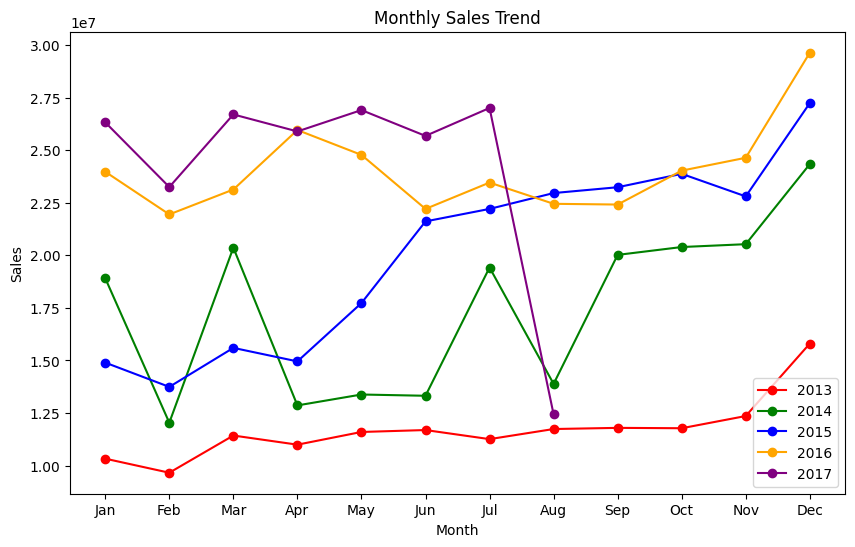

In [33]:
# Group the data by month, year, and calculate the total sales
monthly_sales = train_df.groupby(['month', 'year'])['sales'].sum().reset_index()

# Create the line chart
plt.figure(figsize=(10, 6))  # Set the figure size

# Get unique years and cycle through colors
years = monthly_sales['year'].unique()
colors = itertools.cycle(['red', 'green', 'blue', 'orange', 'purple'])

for year in years:
    year_data = monthly_sales[monthly_sales['year'] == year]
    plt.plot(year_data['month'], year_data['sales'], marker='o', color=next(colors), label=str(year))

plt.xlabel('Month')
plt.ylabel('Sales')
plt.title('Monthly Sales Trend')

# Customize x-axis ticks to show month names
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.xticks(range(1, 13), month_names)


plt.legend()

plt.show()


# Distribution and analysing dataset

<Figure size 1280x960 with 0 Axes>

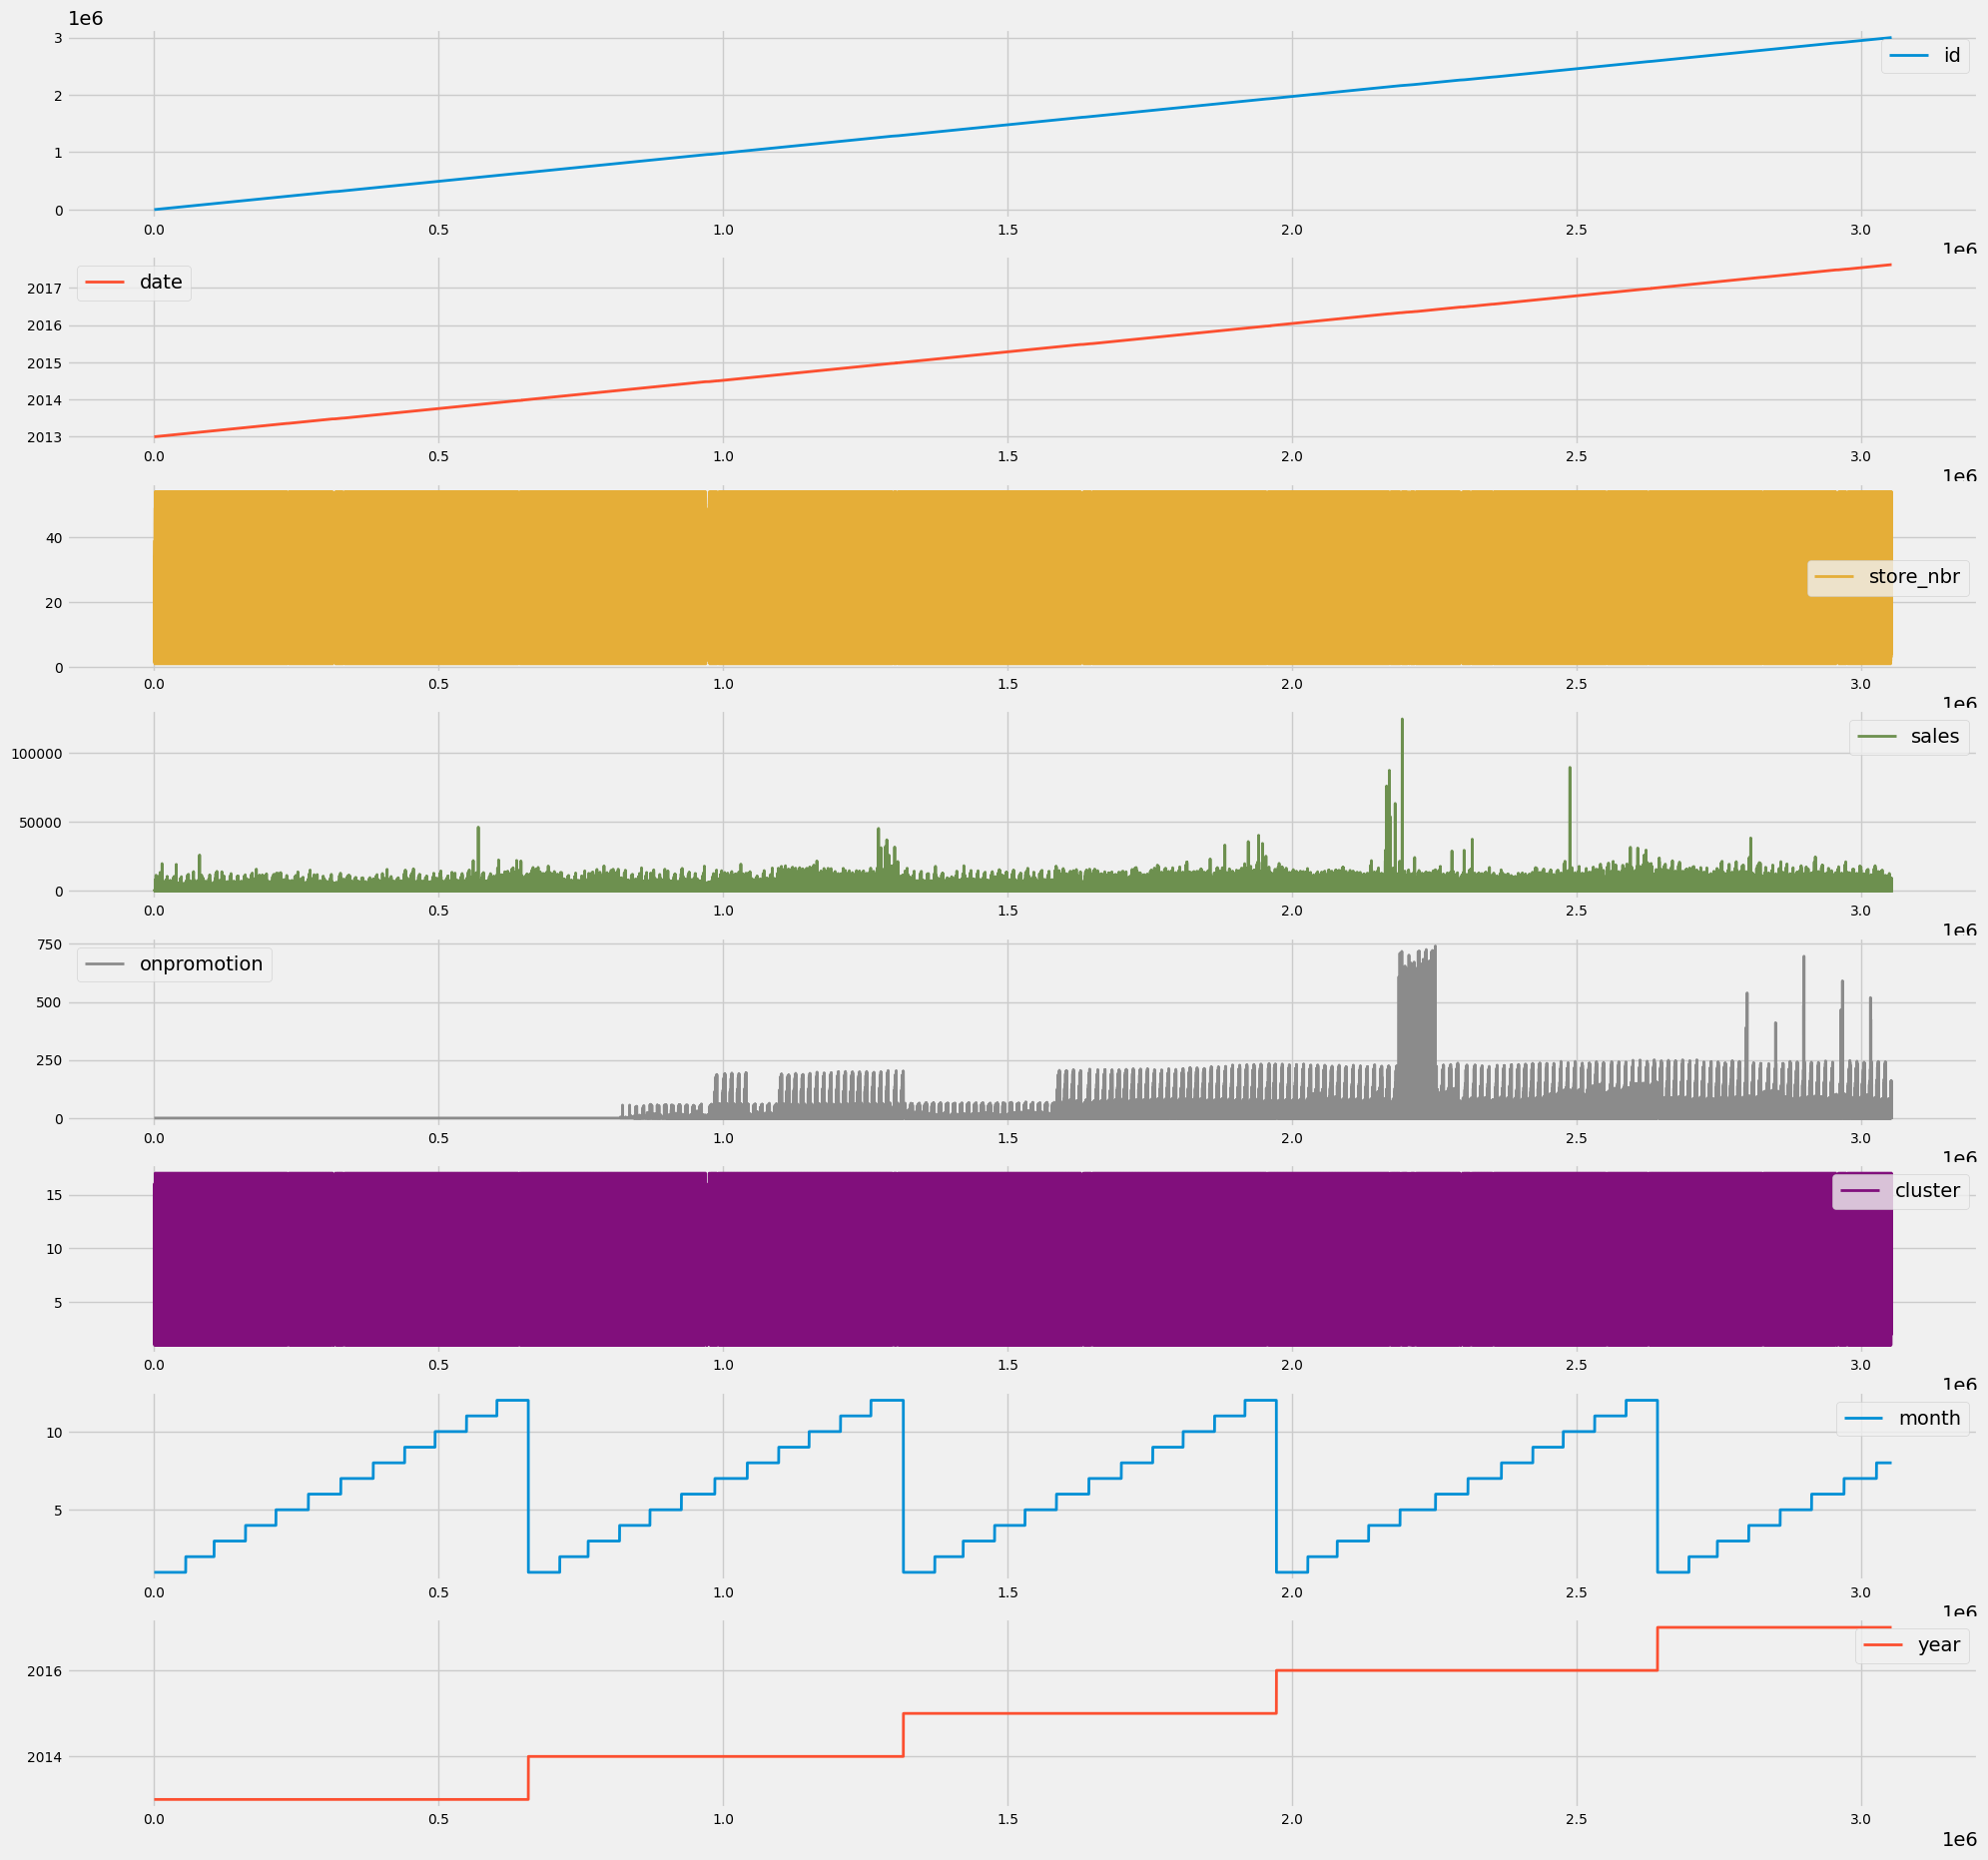

In [34]:
# Visualization of the primary dataset
plt.figure(dpi=200)
plt.style.use('fivethirtyeight')
train_df.plot(subplots=True, figsize=(22, 22), fontsize=10, linewidth=2, sharex=False)
plt.show()

## To Observe 2-weeks Rolling Mean and Std

In [20]:
# finding 2-weeks rolling mean and std
roll_mean = train_df['sales'].rolling(window=2, center=False).mean()
roll_std = train_df['sales'].rolling(window=2, center=False).std()

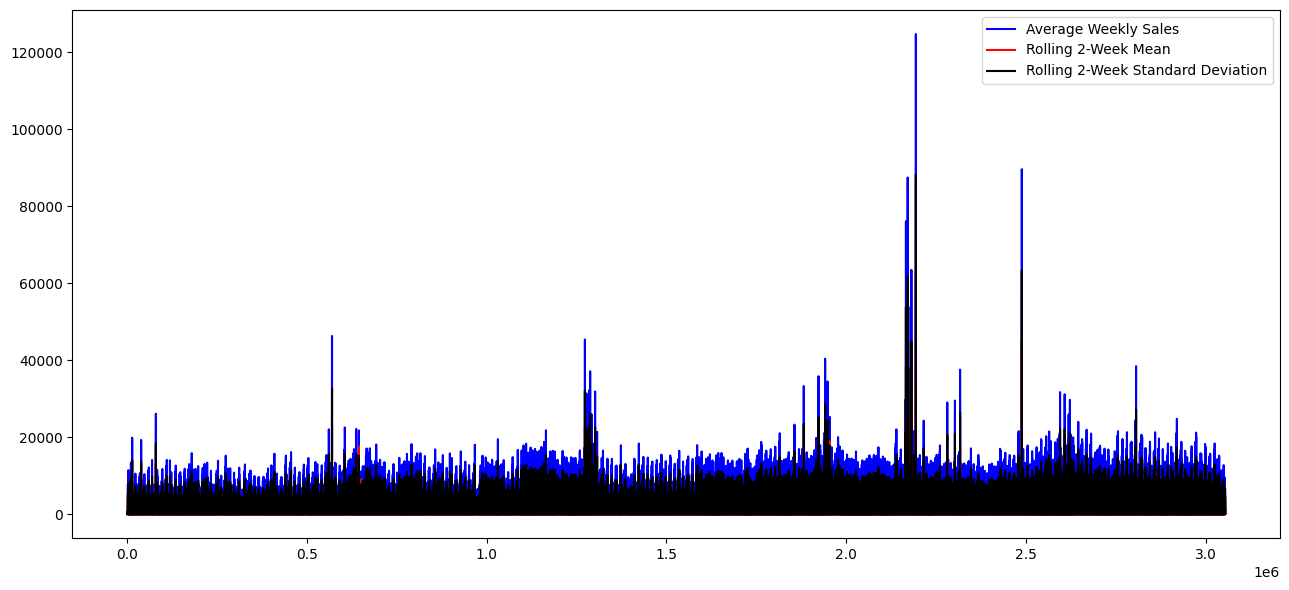

In [21]:
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(train_df['sales'], color='blue',label='Average Weekly Sales')
ax.plot(roll_mean, color='red', label='Rolling 2-Week Mean')
ax.plot(roll_std, color='black', label='Rolling 2-Week Standard Deviation')
ax.legend()
fig.tight_layout()

<div style="border-radius: 5px; font-family: cursive; border: 3px solid #008000; text-align: justify; color: black; font-size: 14px; padding: 10px; background:#F2FFFF;">

  <p style="text-align: justify; font-family: cursive; font-size: 14px; color: green; font-weight: bold;">
        Time Series Analysis: Load and Solar Generation (2016)
    </p>

  <p style="text-align: justify; font-family: cursive; font-size: 14px; color: black;">
        The plot shows both the <strong>load</strong> and <strong>solar generation</strong> over time for the year 2016. 
        The load appears to have a cyclical pattern with peaks and valleys, possibly corresponding to daily patterns of electricity use.
    </p>

  <p style="text-align: justify; font-family: cursive; font-size: 14px; color: black;">
        The solar generation also shows a clear pattern, with generation during the day and no generation at night, as expected. 
        The amount of solar generation also appears to fluctuate throughout the year, likely due to seasonal changes in sunlight.
    </p>

  <p style="text-align: justify; font-family: cursive; font-size: 14px; color: green; font-weight: bold;">
        Importance of Stationarity
    </p>

 <p style="text-align: justify; font-family: cursive; font-size: 14px; color: black;">
        Before moving on to time series analysis and forecasting with ARIMA, it's important to check for <strong>stationarity</strong> in your time series data. 
        Stationarity is a property of time series data that implies the mean, variance, and autocorrelation structure do not change over time. 
        Many time series models, including ARIMA, require the data to be stationary.
    </p>

 <p style="text-align: justify; font-family: cursive; font-size: 14px; color: black;">
        Let's perform an <strong>Augmented Dickey-Fuller (ADF) test</strong> to check the stationarity of the time series. 
        The null hypothesis of the ADF test is that the time series is non-stationary. 
        If the p-value of the test is less than the significance level (0.05), then you reject the null hypothesis 
        and infer that the time series is indeed stationary.
    </p>

</div>


## Does the type of stores affect the store sales?

In [23]:
grouped_data = train_df.groupby('type')['sales']

# Perform the ANOVA test
f_statistic, p_value = stats.f_oneway(*[grouped_data.get_group(type) for type in grouped_data.groups])

# Print the results
print("F-Statistic:", f_statistic)
print("p-value:", p_value)

F-Statistic: 17766.023730362194
p-value: 0.0


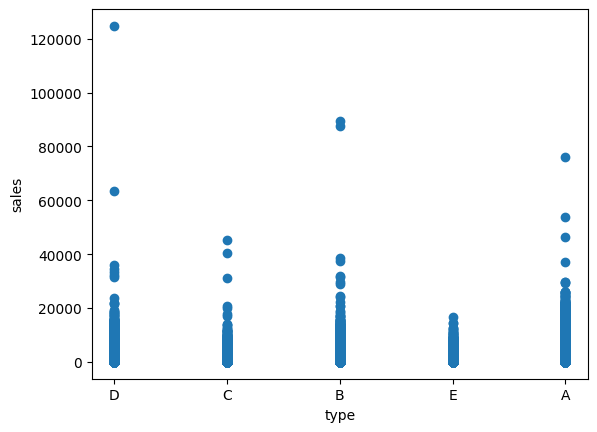

In [24]:
# Sales Vs Type

plt.scatter(train_df['type'], train_df['sales'])

plt.ylabel('sales')
plt.xlabel('type')

plt.show()

<div style="border-radius: 5px; font-family: cursive; border: 3px solid #129900ff; text-align: justify; color: black; font-size: 14px; padding: 10px; background:#F0FFFF;">

  <p style="text-align: justify; font-family: cursive; font-size: 14px; color:black; font-weight: bold;">
     📌 Does the type of stores affect the store sales?
  </p>

  <p style="text-align: justify; font-family: cursive; font-size: 14px;">
      To answer the first research question, <strong>“Does the type of stores affect the store sales?”</strong>, we apply the <strong>ANOVA (Analysis of Variance)</strong> test.
      ANOVA is a statistical method used to determine whether there are significant differences between the means of two or more independent groups.
  </p>

  <p style="text-align: justify; font-family: cursible; font-size: 14px;">
     The idea behind ANOVA is to measure how much of the variation in sales is explained by differences in store types compared to the variation within each type.
  </p>

  <p style="text-align: justify; font-family: cursive; font-size: 14px; color:black; font-weight: bold;">
      Hypotheses
  </p>

  <ul style="font-family: cursive; font-size: 14px;">
      <li><strong>H₀ (p-value > 0.05):</strong> Store type does <strong>not</strong> have an effect on store sales. There is no significant difference between the mean sales of different store types.</li>
      <li><strong>H₁ (p-value < 0.05):</strong> Store type <strong>does</strong> affect store sales. There is a significant difference between the mean sales of different store types.</li>
  </ul>

  <p style="text-align: justify; font-family: cursive; font-size: 14px;">
      Based on the calculated <strong>F-statistics</strong> and <strong>p-value</strong>, we reject the null hypothesis (H₀) and accept the alternative hypothesis (H₁).
      Therefore, the results show that the type of store <strong>does have a statistically significant effect</strong> on sales performance.
  </p>
 <p style="text-align: justify; font-family: cursive; font-size: 14px;">
      Based on the calculated <strong>F-statistics</strong> and <strong>p-value</strong>, ased on the F-statistics and p-value above, we reject null hypothesis and accept alternative hypothesis. Hence, the type of stores does affect the store sales. There is a significant difference in store sales between different type. 
      Therefore, the results show that the type of store <strong>does have a statistically significant effect</strong> on sales performance.
  </p>


  <p style="text-align: justify; font-family: cursive; font-size: 14px; color:black; font-weight: bold;">
      ✔ Conclusion
  </p>

  <p style="text-align: justify; font-family: cursive; font-size: 14px;">
      The type of store significantly influences sales volume. Different store categories lead to different levels of sales performance.
  </p>

</div>


## Which family is having the highest sales?

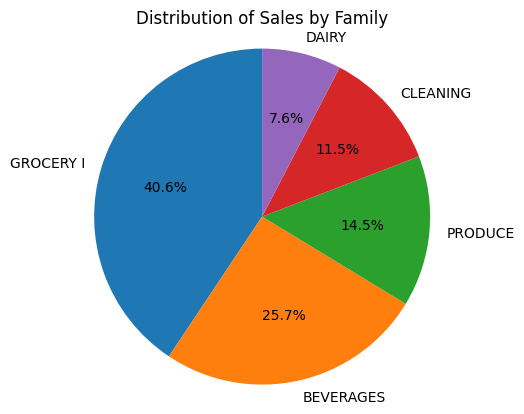

In [25]:
#Pie chart

# Group the data by family and calculate the total sales for each family
family_sales = train_df.groupby('family')['sales'].sum()

# Sort the families based on sales in descending order
family_sales_sorted = family_sales.sort_values(ascending=False)

# Get the top 5 families with the highest sales
top_families = family_sales_sorted.head(5)

# Create the pie chart
plt.pie(top_families, labels=top_families.index, autopct='%1.1f%%', startangle=90)

plt.title('Distribution of Sales by Family')

plt.axis('equal')  
plt.show()

<div style="border-radius: 5px; font-family: cursive; border: 3px solid #009908ff; text-align: justify; color: black; font-size: 14px; padding: 10px; background:#F0FFFF;">

  <p style="text-align: justify; font-family: cursive; font-size: 14px; color:black; font-weight: bold;">
     🟢 Interpretation of the Pie Chart (Sales by Category)
  </p>

  <p style="text-align: justify; font-family: cursive; font-size: 14px;">
      Based on the pie chart displayed above, it can be observed that the <strong>GROCERY I category</strong> contributes the highest sales among all categories. 
      Meanwhile, the <strong>Beverages</strong> category appears as the second highest contributor to overall store sales.
  </p>

  <p style="text-align: justify; font-family: cursive; font-size: 14px;">
      This suggests that grocery-related products play a major role in the revenue distribution of the stores, and beverages also represent a significant contribution within the product portfolio.
  </p>

</div>


## Does promotion able to improve the sales?

In [28]:
correlation, p_value = pearsonr(train_df['onpromotion'], train_df['sales'])

print("Pearson correlation coefficient:", correlation)
print("p-value:", p_value)

Pearson correlation coefficient: 0.42792320481213164
p-value: 0.0


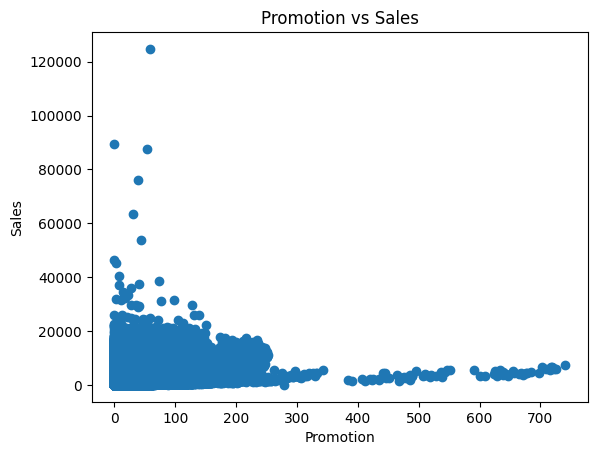

In [29]:
# Scatter plot
plt.scatter(train_df['onpromotion'], train_df['sales'])

plt.xlabel('Promotion')
plt.ylabel('Sales')
plt.title('Promotion vs Sales')

plt.show()

<div style="border-radius: 5px; font-family: cursive; border: 3px solid #008000; 
text-align: justify; color: black; font-size: 14px; padding: 10px; background:#F2FFFF;">

  <p style="text-align: justify; font-family: cursive; font-size: 14px; color: green; font-weight: bold;">
     📌 Relationship Between Promotion and Sales (Pearson Correlation Test)
  </p>

  <p style="text-align: justify;">
      To answer the question <strong>"Does promotion improve the sales?"</strong>, the Pearson correlation test is applied since both variables (<em>promotion</em> and <em>sales</em>) are numerical. The Pearson correlation coefficient measures the linear relationship between two continuous variables, with values ranging between -1 and +1.
  </p>

  <p style="text-align: justify; font-size: 14px; color: green; font-weight: bold;">
       🔍 Statistical Hypotheses
  </p>

  <ul style="font-family: cursive; font-size: 14px;">
      <li><strong>H0 (p &gt; 0.05):</strong> Promotion does not affect store sales.</li>
      <li><strong>H1 (p &lt; 0.05):</strong> Promotion does affect store sales.</li>
  </ul>

  <p style="text-align: justify;">
      Based on the analysis, the Pearson correlation coefficient is found to be 
      <strong>0.4279</strong> and the corresponding <strong>p-value is 0.0</strong>. Since the p-value is lower than 0.05, the null hypothesis <strong>is rejected</strong>.
  </p>

  <p style="text-align: justify;">
      Therefore, it can be concluded that <strong>promotion has a statistically significant relationship with store sales</strong>. This means that promotional activities are associated with an increase in sales performance.
  </p>

</div>


## Which of the stores has the highest sales. 

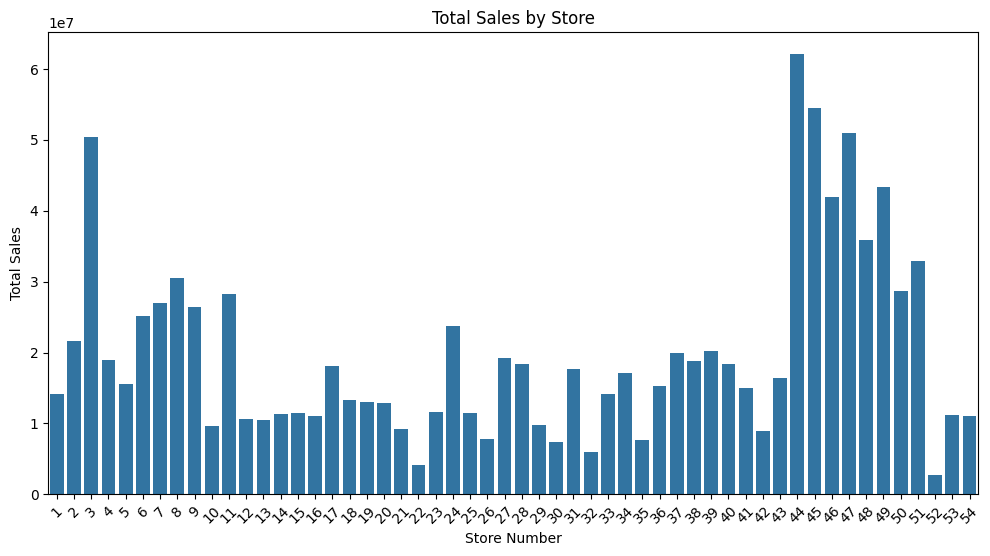

In [30]:
# Calculate the total sales for each store
store_sales = train_df.groupby('store_nbr')['sales'].sum().reset_index()

# Sort the stores based on sales in descending order
store_sales = store_sales.sort_values('sales', ascending=False)

# Create a bar plot
plt.figure(figsize=(12, 6))
sns.barplot(data=store_sales, x='store_nbr', y='sales')

plt.xlabel('Store Number')
plt.ylabel('Total Sales')
plt.title('Total Sales by Store')

plt.xticks(rotation=45)

plt.show()

<Figure size 1280x960 with 0 Axes>

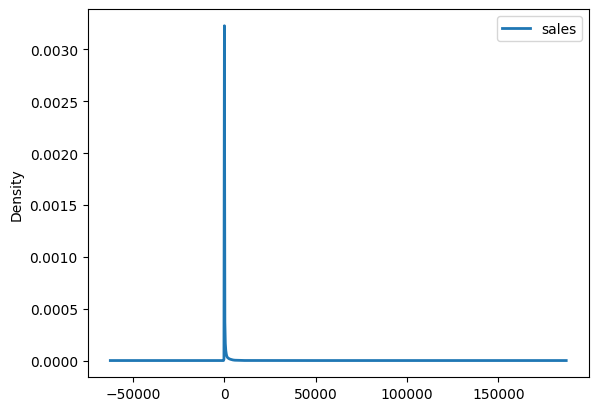

In [34]:
df_col = train_df.select_dtypes(include=['float']).columns

#disribution of the primary dataset
plt.figure(dpi=200)
train_df[df_col].plot(kind='density',subplots=True,layout=(4, 3), figsize=(22,22),
           fontsize=10, linewidth=2, sharex=False);
plt.show()

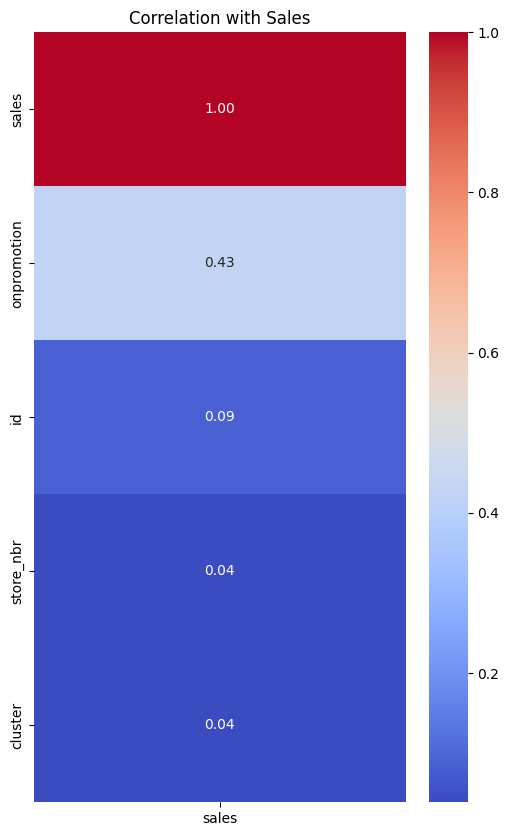

In [37]:
numeric_cols = train_df.select_dtypes(include=['number'])
correlation_matrix = numeric_cols.corr()

sales_corr = correlation_matrix['sales'].abs().sort_values(ascending=False)

plt.figure(figsize=(6, 10))
sns.heatmap(sales_corr.to_frame(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation with Sales")
plt.show()


<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
      Check for stationarity by Adfuller
</center></p></h1>



<div style="border-radius: 5px; font-family: cursive; border: 3px solid #008000; 
text-align: justify; color: black; font-size: 14px; padding: 12px; background:#F2FFFF;">

  <p style="font-size: 14px; color: green; font-weight: bold;">
      📊 Augmented Dickey-Fuller (ADF) Test
  </p>

  <p>
      The <strong>Augmented Dickey-Fuller (ADF) test</strong> is a statistical test used to determine whether a time series is 
      <strong>stationary or non-stationary</strong>. Stationarity is extremely important in many time series models such as ARIMA.
  </p>

  <p>
     The ADF test evaluates the <strong>null hypothesis</strong> that the time series contains a <em>unit root</em>, meaning 
     that it is <strong>non-stationary</strong>. The alternative hypothesis suggests the series <strong>is stationary</strong>.
  </p>

  <p>
     When running the ADF test, two values are mainly interpreted:
  </p>

  <ul style="font-family: cursive; font-size: 14px;">
      <li><strong>ADF Statistic</strong> – negative value, the more negative → stronger evidence of stationarity</li>
      <li><strong>p-value</strong> – if below <strong>0.05</strong>, reject the null hypothesis</li>
  </ul>

  <p>
     A low p-value indicates strong evidence against the presence of a unit root and therefore supports that 
     the <strong>time series is stationary</strong>.
  </p>

  <p style="font-size: 14px; color: green; font-weight: bold;">
      ✔ Key Insights
  </p>

  <ul style="font-family: cursive; font-size: 14px;">
      <li>Time series <strong>must be stationary</strong> before applying ARIMA</li>
      <li><strong>AIC optimization</strong> helps select the best ARIMA parameters</li>
      <li>ARIMA is effective for data with <strong>trend</strong> and <strong>seasonality</strong></li>
  </ul>

</div>



In [43]:
train_df['date'] = pd.to_datetime(train_df['date'], errors='coerce')
train_df = train_df.set_index('date')

series = train_df['sales'].resample('D').sum()

adf_result = adfuller(series.dropna(), maxlag=10)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])


ADF Statistic: -3.6477431016955943
p-value: 0.004911210190185191


<div style="border-radius: 5px; font-family: cursive; border: 3px solid #008000; text-align: justify; color: black; font-size: 14px; padding: 10px; background:#F2FFFF;">

   <p style="text-align: justify; font-family: cursive; font-size: 14px; color: green; font-weight: bold;">
        Augmented Dickey-Fuller Test Results
    </p>

 <p style="text-align: justify; font-family: cursive; font-size: 14px; color: black;">
        For <strong>'IT_load_new'</strong>: The p-value is extremely small (much less than 0.05), so we reject the null hypothesis 
        that the time series is non-stationary. Therefore, <strong>'IT_load_new'</strong> can be considered stationary.
    </p>

 <p style="text-align: justify; font-family: cursive; font-size: 14px; color: black;">
        For <strong>'IT_solar_generation'</strong>: The p-value is also very small (much less than 0.05), so we reject the null hypothesis. 
        This means <strong>'IT_solar_generation'</strong> can be considered stationary as well.
    </p>

 <p style="text-align: justify; font-family: cursive; font-size: 14px; color: green; font-weight: bold;">
        Proceeding with ARIMA Modeling
    </p>

 <p style="text-align: justify; font-family: cursive; font-size: 14px; color: black;">
        Since both series are stationary, we can proceed with building an <strong>ARIMA model</strong> for each of them.
    </p>

<p style="text-align: justify; font-family: cursive; font-size: 14px; color: black;">
        ARIMA stands for <strong>AutoRegressive Integrated Moving Average</strong>. It explains a given time series 
        based on its own past values (lags) and lagged forecast errors. This model can be used to forecast future values.
    </p>

 <p style="text-align: justify; font-family: cursive; font-size: 14px; color: black;">
        Any non-seasonal time series that exhibits patterns and is not random white noise can be modeled with ARIMA.
    </p>

 <p style="text-align: justify; font-family: cursive; font-size: 14px; color: black;">
        An ARIMA model is characterized by three terms: <strong>p, d, q</strong>:
        <ul>
            <li><strong>p</strong>: Order of the AR term (number of lags of Y to be used as predictors).</li>
            <li><strong>d</strong>: Number of differencing required to make the series stationary.</li>
            <li><strong>q</strong>: Order of the MA term (moving average).</li>
        </ul>
        In our case, since the series are already stationary, <strong>d = 0</strong> for both series. 
        We need to determine the optimal values for <strong>p</strong> and <strong>q</strong> using the 
        <strong>ACF (Autocorrelation Function)</strong> and <strong>PACF (Partial Autocorrelation Function)</strong> plots.
    </p>

</div>


<div style="border-radius: 5px; font-family: cursive; border: 3px solid #008000; text-align: justify; color: black; font-size: 14px; padding: 10px; background:#F2FFFF;">

  <p style="text-align: justify; font-family: cursive; font-size: 14px; color: green; font-weight: bold;">
        Augmented Dickey-Fuller (ADF) Test Results
    </p>

  <p style="font-family: cursive; font-size: 14px; color: black;">
        The ADF test was applied to evaluate whether the time series is <strong>stationary</strong>.  
        The following results were obtained:
    </p>

<ul style="font-family: cursive; font-size: 14px; color: black;">
        <li><strong>ADF Statistic:</strong> -3.64</li>
        <li><strong>p-value:</strong> 0.004</li>
    
    </ul>

 <p style="font-family: cursive; font-size: 14px; color: black;">
        The <strong>p-value is extremely small</strong> (far below 0.05), allowing us to 
        <strong>reject the null hypothesis</strong> that the series is non-stationary.  
        This confirms that the time series is <strong>stationary</strong>.
    </p>

  <p style="font-family: cursive; font-size: 14px; color: black;">
        Additionally, the <strong>ADF Statistic = -3.64</strong> is much lower (more negative) 
        than all critical values at 1%, 5%, and 10% significance levels.  
        This strongly supports the conclusion that the series <strong>does not have a unit root</strong>.
    </p>

   <p style="text-align: justify; font-family: cursive; font-size: 14px; color: green; font-weight: bold;">
        Interpretation
    </p>

  <p style="font-family: cursive; font-size: 14px; color: black;">
        Based on the results, the series is <strong>fully stationary</strong> and suitable for time-series modeling 
        such as <strong>ARIMA</strong>, <strong>SARIMA</strong>, <strong>VAR</strong>, or <strong>Machine Learning</strong> forecasting methods 
        without requiring further differencing.
    </p>

 <p style="font-family: cursive; font-size: 14px; color: black;">
        If you plan to use ARIMA, the <strong>d parameter should be 0</strong> since stationarity is already achieved.
    </p>

</div>


<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
     Method for stationarity
</center></p></h1>

## Differencing 

In [ ]:

# This process is meant to transform the time series data to stationary, as ARIMA model only works with stationary time series data. 
train_df['diff_sales'] = train_df['sales'].diff()
print(train_df['diff_sales'])

date
2013-01-01         NaN
2013-01-01       0.000
2013-01-01       0.000
2013-01-01       0.000
2013-01-01       0.000
                ...   
2017-08-15     432.133
2017-08-15    -283.580
2017-08-15    2265.176
2017-08-15   -2298.729
2017-08-15    -105.000
Name: diff_sales, Length: 3000888, dtype: float64


## ARIMA / ARIMAX / SARIMA / SARIMAX

In [12]:
train_size = int(len(df) * 0.8)
train = df[:train_size]
test = df[train_size:]

In [12]:
# --- 3) انتخاب سری مورد نظر برای مدل (مثلاً Load) ---
series = df['IT_load_new']  # یا هر ستون مد نظرت

# --- 4) تقسیم Train/Test 80/20 ---
train_size = int(len(series) * 0.8)
train, test = series[:train_size], series[train_size:]
print("Train length:", len(train), "Test length:", len(test))

Train length: 7027 Test length: 1757


In [13]:
print(f"shape of x train: {train.shape}")
print(f"shape of x test: {test.shape}")

shape of x train: (7027, 3)
shape of x test: (1757, 3)


In [45]:
series = train_df['sales']
train_size = int(len(series) * 0.8)
train = series[:train_size]
test  = series[train_size:train_size + 24]   # فقط 24 نقطه

In [46]:
print(train.dtype)
print(train.head())
print(type(train))

float64
date
2013-01-01    0.0
2013-01-01    0.0
2013-01-01    0.0
2013-01-01    0.0
2013-01-01    0.0
Name: sales, dtype: float64
<class 'pandas.core.series.Series'>


In [47]:
train


date
2013-01-01      0.000
2013-01-01      0.000
2013-01-01      0.000
2013-01-01      0.000
2013-01-01      0.000
               ...   
2016-09-12     26.000
2016-09-12      9.000
2016-09-12      1.000
2016-09-12    170.509
2016-09-12    181.000
Name: sales, Length: 2400710, dtype: float64

<a id="1"></a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px"> Models</p>
</div>

# ================================
# ARIMA

# ================================


In [48]:
p = 2
d = 1 
q = 1

In [ ]:

# Fit the ARIMA model
model = ARIMA(train, order=(p,d,q))
model_fit = model.fit()


# Print the model summary
print(model_fit.summary())

# Make predictions on the test set
predictions = model_fit.predict(start=len(train), end=len(train)+len(test)-1)
# Print the predictions
print(predictions)


# Calculate RMSE
rmse = sqrt(mean_squared_error(test, predictions))
# Print the evaluation metrics
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)

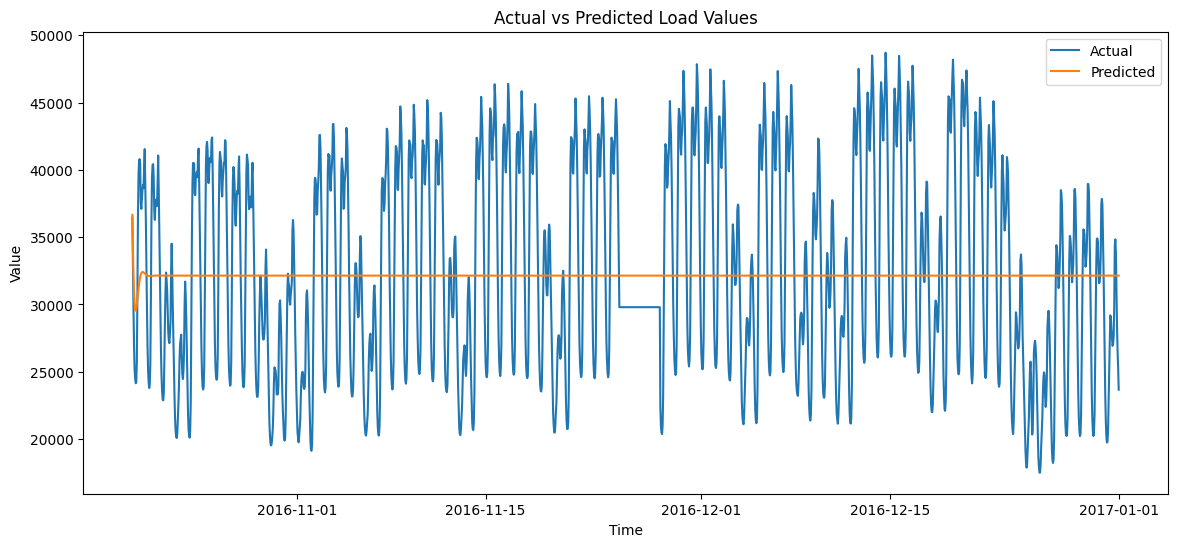

In [ ]:
# =========================
# 3. Plot results
# =========================
plt.figure(figsize=(14,6))
plt.plot(train_df, label='Train')
plt.plot(test_df, label='Test')
plt.plot(y_pred_arima, label='ARIMA Prediction', color='red')
plt.title('Weekly Sales Forecast using ARIMA')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.legend()
plt.show()

<div style="border-radius: 5px; font-family: cursive; border: 3px solid #008000; text-align: justify; color: black; font-size: 14px; padding: 15px; background:#F2FFFF;">

  <p style="font-size: 16px; color: green; font-weight: bold; text-align:center;">
        📊 ARIMA Model Performance: IT_load_new vs Test Set
    </p>

<p>
        The plot shows the <strong>actual versus predicted load values</strong> for the test set. 
        The ARIMA model is able to capture the general pattern and structure of the time series data. 
        However, some differences between the actual and predicted values still remain.
    </p>

 <p style="color:green; font-weight:bold;">📌 Possible Reasons for Discrepancies</p>
    <ul>
        <li>Inherent randomness in the electricity load data.</li>
        <li>Other external factors that are not included in the model.</li>
        <li>Limitations of the ARIMA model itself, which assumes linear relationships.</li>
    </ul>

 <p>
        More complex models or additional data preprocessing steps could potentially improve the prediction results.
    </p>

 <p style="color:green; font-weight:bold;">📈 Next Steps: IT_solar_generation</p>
    <p>
        We will repeat the same forecasting process for the <strong>'IT_solar_generation'</strong> time series. 
        The first step is to plot the <strong>ACF (Autocorrelation Function)</strong> and <strong>PACF (Partial Autocorrelation Function)</strong> 
        to help determine the optimal parameters (p, d, q) for the ARIMA model.
    </p>





<div style="text-align:center; padding:10px;">
        <img src="YOUR_PLOT_IMAGE.png" style="width:90%; border-radius:10px; border:2px solid #008000;">
        <p style="font-size:12px; color:#555;">(Replace this image with the actual vs predicted plot for IT_load_new)</p>
    </div>

</div>


<a id="1"></a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px"> ACF & PACF Plots</p>
</div>

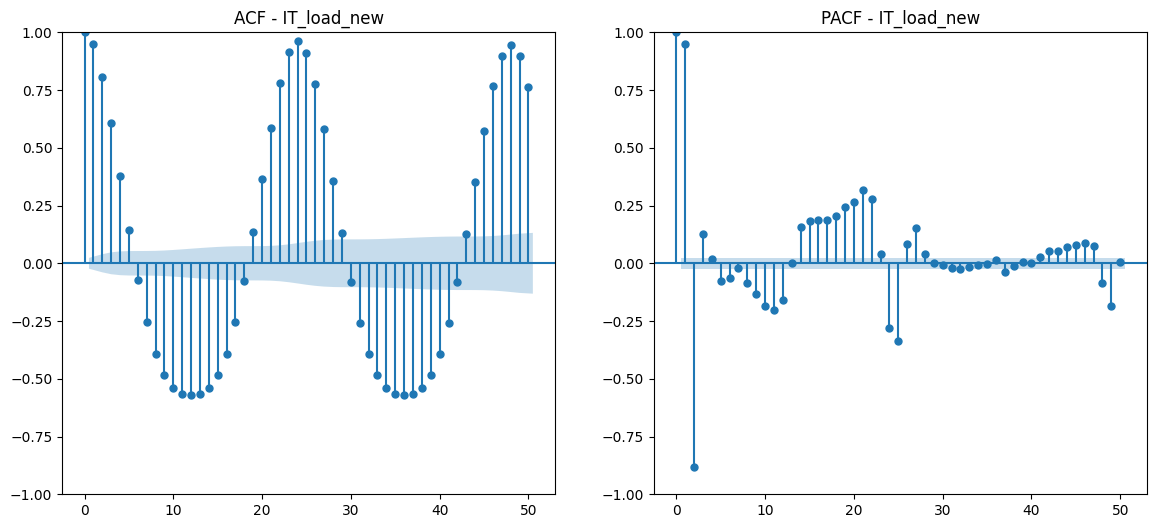

In [38]:


# Plot ACF and PACF for IT_load_new
plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plot_acf(train, lags=50, ax=plt.gca())
plt.title("ACF - IT_load_new")

plt.subplot(1,2,2)
plot_pacf(train, lags=50, ax=plt.gca())
plt.title("PACF - IT_load_new")

plt.show()
